Connect to Server


In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# 1. Define your connection parameters
server = r"YOUR_SERVER\SQLEXPRESS" 
database = "PetrochemicalAnalytics"
driver = "ODBC Driver 17 for SQL Server"  # Ensure this driver is installed on your machine

# Choose one authentication method below:

# OPTION A: Windows Authentication (Trusted Connection)
connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

# OPTION B: SQL Server Authentication (Username & Password)
# username = 'YOUR_USERNAME'
# password = 'YOUR_PASSWORD'
# connection_string = f"DRIVER={{{driver}}};SERVER={server};DATABASE={database};UID={username};PWD={password};"

# 2. Encode the connection string for SQLAlchemy
params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# 3. Query data directly into a Pandas DataFrame
df_catalyst = pd.read_sql(
    "SELECT * FROM [Gold].[dim_catalyst]",
    engine
)

df_time = pd.read_sql(
    "SELECT * FROM [Gold].[dim_time]",
    engine
)

df_unit = pd.read_sql(
    "SELECT * FROM [Gold].[dim_unit]",
    engine
)

df_operations = pd.read_sql(
    "SELECT * FROM [Gold].[fact_plant_operations]",
    engine
)


Merge keys to fact table


In [67]:
df_analysis = (
    df_operations
    .merge(
        df_catalyst[['catalyst_key', 'catalyst_type']],
        on='catalyst_key',
        how='left'
    )
    .merge(
        df_unit[['unit_key', 'unit_name']],
        on='unit_key',
        how='left'
    )
    .merge(
        df_time[['time_key', 'full_timestamp', 'date_only',
                 'year', 'month', 'month_name', 'day', 'hour', 'shift']],
        on='time_key',
        how='left'
    )
)

In [68]:
df_analysis.head()

,time_key,unit_key,catalyst_key,catalyst_age_days,sensor_health_index,vibration_level_mm_s,valve_opening_percent,feedstock_flow_m3h,reactor_temp_c,reactor_pressure_bar,...,catalyst_type,unit_name,full_timestamp,date_only,year,month,month_name,day,hour,shift
0,1,3,2,228,30.668569,3.571037,42.267804,640.205985,822.794549,0.937144,...,IRON_STANDARD_V5,METHANOL_COMPLEX_03,2020-01-01 00:00:00,2020-01-01,2020,1,January,1,0,Night
1,2,2,1,298,29.674219,1.445883,40.560540,589.343157,788.934016,0.741007,...,COBALT_PREMIUM_Z2,ETHYLENE_PLANT_01,2020-01-01 04:00:00,2020-01-01,2020,1,January,1,4,Night
2,3,3,1,291,30.405398,5.039982,70.770179,560.421904,777.986030,0.808593,...,COBALT_PREMIUM_Z2,METHANOL_COMPLEX_03,2020-01-01 08:00:00,2020-01-01,2020,1,January,1,8,Morning
3,4,3,3,67,33.056442,8.118884,89.613827,666.987789,764.710838,0.808416,...,PLATINUM_BASE_X1,METHANOL_COMPLEX_03,2020-01-01 12:00:00,2020-01-01,2020,1,January,1,12,Morning
4,5,2,1,251,27.519881,4.840103,39.065391,634.584262,769.089667,0.827154,...,COBALT_PREMIUM_Z2,ETHYLENE_PLANT_01,2020-01-01 16:00:00,2020-01-01,2020,1,January,1,16,Evening


## **'Analysis_1 - Overall understanding (EDA)'**




In [69]:
eda_columns = [
    'product_yield_tons',
    'energy_intensity',
    'reactor_temp_c',
    'reactor_pressure_bar',
    'feedstock_flow_m3h',
    'vibration_level_mm_s'
]

df_analysis[eda_columns].describe()

,product_yield_tons,energy_intensity,reactor_temp_c,reactor_pressure_bar,feedstock_flow_m3h,vibration_level_mm_s
count,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,80.216182,2.885240,819.448218,0.809195,550.720553,4.475282
std,14.081122,0.625216,40.216568,0.110208,59.895310,2.308131
min,40.620501,1.331305,675.824163,0.560232,341.033898,0.500819
25%,70.160071,2.433578,792.894695,0.731169,510.237082,2.499328
50%,79.577280,2.806401,819.105513,0.800586,550.745125,4.472033
75%,89.783693,3.255966,846.302090,0.901888,591.553576,6.463170
max,133.977440,6.386947,966.361150,0.999947,758.514363,8.499197


 Product Yield Distribution

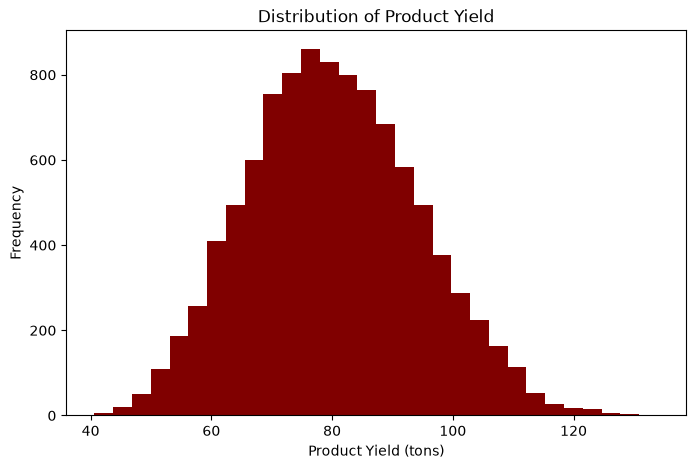

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_analysis['product_yield_tons'],
    bins=30,
    color='maroon'
)

plt.xlabel('Product Yield (tons)')
plt.ylabel('Frequency')
plt.title('Distribution of Product Yield')

plt.show()

Energy Intensity Distribution


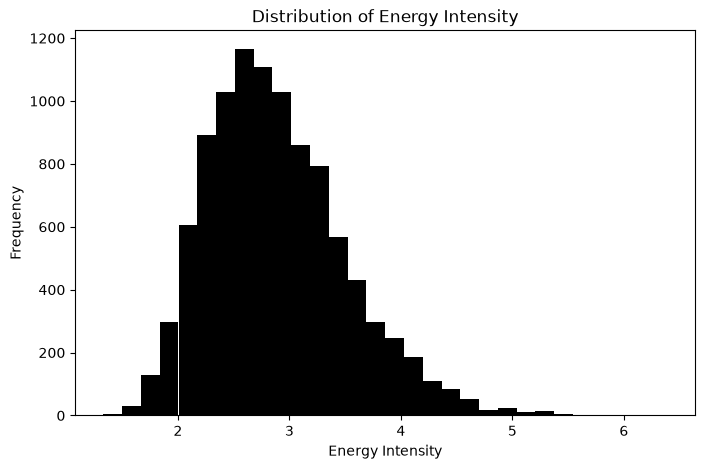

In [71]:
plt.figure(figsize=(8,5))

plt.hist(
    df_analysis['energy_intensity'],
    bins=30,
    color = 'black'
)

plt.xlabel('Energy Intensity')
plt.ylabel('Frequency')
plt.title('Distribution of Energy Intensity')

plt.show()

Reactor Temperature

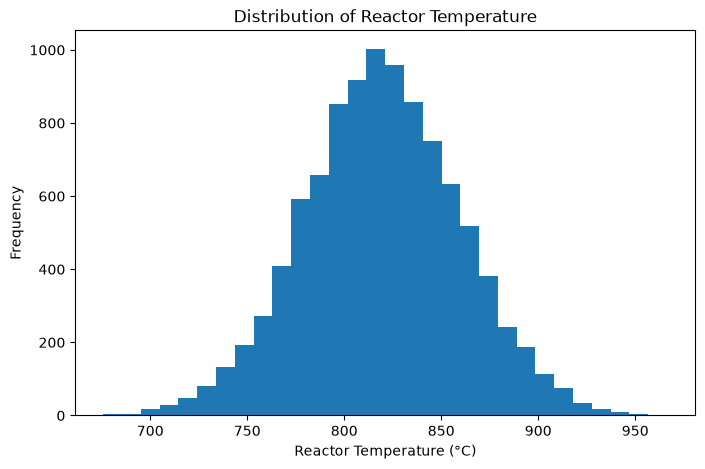

In [72]:
plt.figure(figsize=(8,5))

plt.hist(
    df_analysis['reactor_temp_c'],
    bins=30
)

plt.xlabel('Reactor Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Reactor Temperature')

plt.show()

Reactor Pressure

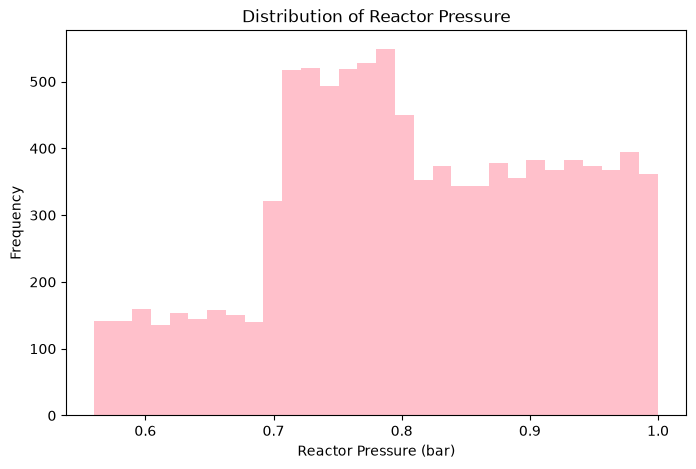

In [73]:
plt.figure(figsize=(8,5))

plt.hist(
    df_analysis['reactor_pressure_bar'],
    bins=30,
    color = 'pink'
)

plt.xlabel('Reactor Pressure (bar)')
plt.ylabel('Frequency')
plt.title('Distribution of Reactor Pressure')

plt.show()

Feedstock Flow

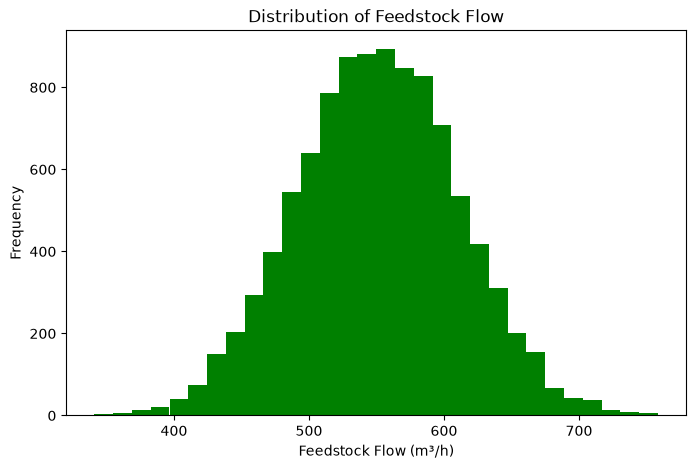

In [74]:
plt.figure(figsize=(8,5))

plt.hist(
    df_analysis['feedstock_flow_m3h'],
    bins=30,
    color = 'green'
)

plt.xlabel('Feedstock Flow (m³/h)')
plt.ylabel('Frequency')
plt.title('Distribution of Feedstock Flow')

plt.show()

Vibration


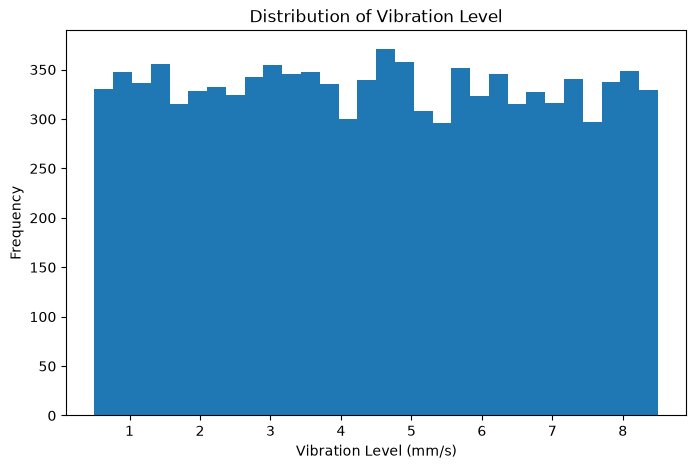

In [75]:
plt.figure(figsize=(8,5))

plt.hist(
    df_analysis['vibration_level_mm_s'],
    bins=30
)

plt.xlabel('Vibration Level (mm/s)')
plt.ylabel('Frequency')
plt.title('Distribution of Vibration Level')

plt.show()

> **Observation:** Product yield, energy intensity, reactor temperature, and feedstock flow are mainly concentrated around their central ranges. Reactor pressure shows multiple distinct clusters, indicating different operating regimes, while vibration shows a distinct pattern that will be investigated further in the equipment-health analysis.

## **'Analysis_2 - Production Performance'**

In [76]:
df_analysis['product_yield_tons'].describe()

count    9999.000000
mean       80.216182
std        14.081122
min        40.620501
25%        70.160071
50%        79.577280
75%        89.783693
max       133.977440
Name: product_yield_tons, dtype: float64

Unit-Wise Performance

In [77]:
unit_performance = df_analysis.groupby('unit_name')['product_yield_tons'].agg(
    ['mean', 'min', 'max', 'std']
).sort_values('mean', ascending=False)

unit_performance

,mean,min,max,std
unit_name,,,,
ETHYLENE_PLANT_01,80.382193,45.108634,128.615889,14.102903
AMMONIA_UNIT_02,80.257999,40.620501,130.333701,14.161947
METHANOL_COMPLEX_03,80.004991,42.203078,133.977440,13.977999


The plant shows an average production yield of 80.22 tons, with a median of 79.58 tons, indicating no strong skewness in the production distribution. The standard deviation of 14.08 tons shows noticeable variability around the average, while production ranges from 40.62 to 133.98 tons. Unit-wise, average production is very similar across all three units (80.00–80.38 tons), with Ethylene Plant 01 having the highest mean yield. Methanol Complex 03 is slightly more consistent, while Ammonia Unit 02 shows the highest variability. Overall, production performance is broadly similar across units, with noticeable variation in output.



Catalyst Wise Performance

In [78]:
catalyst_performance = df_analysis.groupby('catalyst_type')['product_yield_tons'].agg(
    ['mean', 'min', 'max', 'std']
).sort_values('mean', ascending=False)

catalyst_performance

,mean,min,max,std
catalyst_type,,,,
IRON_STANDARD_V5,80.273495,40.620501,133.977440,14.230309
COBALT_PREMIUM_Z2,80.273129,42.203078,130.333701,13.746840
PLATINUM_BASE_X1,80.103755,42.572282,128.615889,14.263458


RESULTS: Catalyst-wise average production is almost identical, with IRON_STANDARD_V5 and COBALT_PREMIUM_Z2 showing the highest mean yield (~80.27 tons), while PLATINUM_BASE_X1 is slightly lower (~80.10 tons). COBALT_PREMIUM_Z2 has the lowest standard deviation (13.75 tons), indicating relatively more consistent production, whereas PLATINUM shows slightly higher variability. IRON records both the highest maximum (133.98 tons) and lowest minimum (40.62 tons), indicating the widest observed production range. Overall, no major difference in average production is observed across catalysts, although Cobalt appears slightly more consistent.

Shift - Wise Performance

In [79]:
shift_performance = df_analysis.groupby('shift')['product_yield_tons'].agg(
    ['mean', 'min', 'max', 'std']
).sort_values('mean', ascending=False)

shift_performance

,mean,min,max,std
shift,,,,
Morning,80.599896,42.648202,133.977440,14.138588
Night,80.042066,42.203078,125.635134,13.944694
Evening,80.006573,40.620501,129.945155,14.155533


RESULTS: Shift-wise average production is broadly similar, with Morning showing the highest mean yield (80.60 tons). Night shift is slightly more consistent due to its lowest standard deviation (13.94 tons), while Evening shows the highest variability. Overall, shift-wise differences are small, indicating no major production-performance difference across shifts.

Unit + Catalyst combination

In [80]:
unit_catalyst = df_analysis.groupby(
    ['unit_name', 'catalyst_type']
)['product_yield_tons'].agg(
    ['mean', 'min', 'max', 'std']
).sort_values('mean', ascending=False)

unit_catalyst

mean        min         max  \
unit_name           catalyst_type                                         
ETHYLENE_PLANT_01   IRON_STANDARD_V5   80.505533  47.160601  127.673342   
                    COBALT_PREMIUM_Z2  80.393353  45.195553  124.136233   
AMMONIA_UNIT_02     IRON_STANDARD_V5   80.327959  40.620501  119.811188   
                    PLATINUM_BASE_X1   80.311603  42.648202  124.479731   
METHANOL_COMPLEX_03 COBALT_PREMIUM_Z2  80.290383  42.203078  129.945155   
ETHYLENE_PLANT_01   PLATINUM_BASE_X1   80.248565  45.108634  128.615889   
AMMONIA_UNIT_02     COBALT_PREMIUM_Z2  80.133983  47.289649  130.333701   
METHANOL_COMPLEX_03 IRON_STANDARD_V5   79.982710  42.772209  133.977440   
                    PLATINUM_BASE_X1   79.747242  42.572282  123.626576   

                                             std  
unit_name           catalyst_type                 
ETHYLENE_PLANT_01   IRON_STANDARD_V5   14.289505  
                    COBALT_PREMIUM_Z2  13.738197  
AMMONIA_UNIT_02     IRON_STANDARD_V5   14.102470  
                    PLATINUM_BASE_X1   14.530186  
METHANOL_COMPLEX_03 COBALT_PREMIUM_Z2  13.663952  
ETHYLENE_PLANT_01   PLATINUM_BASE_X1   14.290655  
AMMONIA_UNIT_02     COBALT_PREMIUM_Z2  13.847683  
METHANOL_COMPLEX_03 IRON_STANDARD_V5   14.306188  
                    PLATINUM_BASE_X1   13.965091

RESULTS: Unit–catalyst combinations show very similar average production, with mean yields ranging from 79.75 to 80.51 tons. Ethylene Plant 01 with Iron Standard V5 records the highest average yield, while Methanol Complex 03 with Cobalt Premium Z2 shows the lowest variability (std = 13.66 tons), indicating the most consistent output. Overall, unit–catalyst combinations do not show major differences in average production, although some differences in consistency are observed.

In [81]:
df_analysis['full_timestamp'] = pd.to_datetime(
    df_analysis['full_timestamp']
)

Time-wise production performance

In [82]:
df_analysis['year_month'] = df_analysis['full_timestamp'].dt.to_period('M')

monthly_production = df_analysis.groupby('year_month')['product_yield_tons'].agg(
    ['mean', 'min', 'max', 'std']
)

monthly_production

,mean,min,max,std
year_month,,,,
2020-01,79.810298,45.756552,113.349238,13.171204
2020-02,78.178272,42.203078,113.839228,14.516372
2020-03,79.830113,43.685405,117.950706,14.469847
2020-04,82.208221,47.289649,113.754163,13.700405
2020-05,80.102102,47.549693,117.334120,13.765685
2020-06,79.661950,47.178338,116.635325,15.082804
2020-07,79.662723,47.405407,119.957249,14.881981
2020-08,79.384815,43.805930,111.989630,12.358564
2020-09,80.097532,52.215482,119.602452,13.970449


RESULT: Monthly production remains relatively stable around 80 tons, with no clear long-term increasing or decreasing trend. The highest average yield is observed in December 2022 (83.01 tons), while the lowest is in February 2020 (78.18 tons). Monthly variability also fluctuates, with standard deviation ranging from 12.36 to 15.64 tons. Overall, production shows month-to-month fluctuations rather than a sustained upward or downward trend.

Monthly Production Trend

<Axes: xlabel='year_month'>

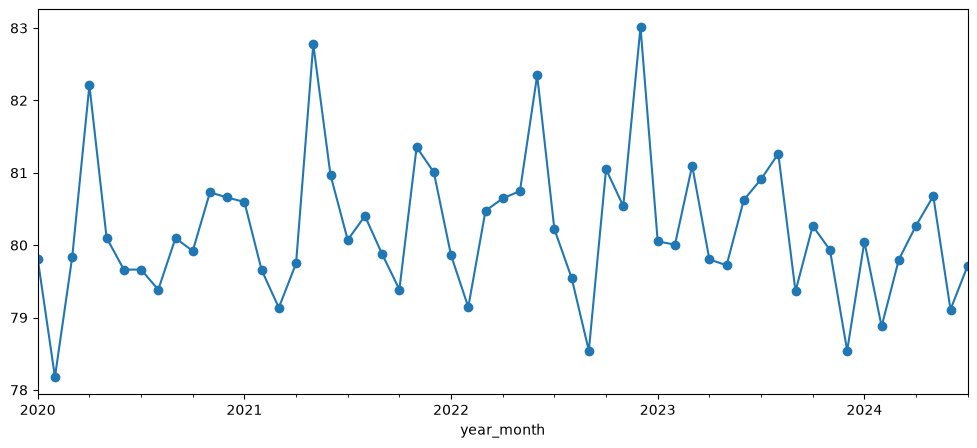

In [83]:
monthly_production['mean'].plot(
    kind='line',
    figsize=(12,5),
    marker='o'
)

RESULTS: The monthly production trend shows frequent fluctuations, with production alternating between higher and lower levels rather than following a consistent upward or downward trend. Overall, production remains relatively stable around 80 tons.

Unit + Shift


In [84]:
unit_shift = df_analysis.groupby(
    ['unit_name', 'shift']
)['product_yield_tons'].mean().unstack()

unit_shift

shift,Evening,Morning,Night
unit_name,,,
AMMONIA_UNIT_02,80.119341,80.670873,79.980927
ETHYLENE_PLANT_01,80.402940,80.713307,80.024874
METHANOL_COMPLEX_03,79.485375,80.408248,80.118193


RESULTS: Morning shift shows the highest average production across all three units, while Night shift generally records lower production. The most noticeable shift-level variation is observed in Methanol Complex 03, where Evening production is lower than Morning and Night. However, the absolute differences remain small, so shift-wise performance is broadly similar across units.

Unit + Catalyst + Shift


In [85]:
# for best performance
combination_performance = df_analysis.groupby(
    ['unit_name', 'catalyst_type', 'shift']
)['product_yield_tons'].mean().sort_values(ascending=False)
combination_performance.head(10)    

unit_name            catalyst_type      shift  
METHANOL_COMPLEX_03  PLATINUM_BASE_X1   Morning    81.618834
AMMONIA_UNIT_02      COBALT_PREMIUM_Z2  Morning    81.307548
ETHYLENE_PLANT_01    COBALT_PREMIUM_Z2  Morning    81.164778
AMMONIA_UNIT_02      IRON_STANDARD_V5   Morning    81.140472
ETHYLENE_PLANT_01    IRON_STANDARD_V5   Morning    81.019283
METHANOL_COMPLEX_03  COBALT_PREMIUM_Z2  Night      80.958323
ETHYLENE_PLANT_01    IRON_STANDARD_V5   Evening    80.846719
AMMONIA_UNIT_02      PLATINUM_BASE_X1   Evening    80.698785
                                        Night      80.662566
ETHYLENE_PLANT_01    PLATINUM_BASE_X1   Night      80.654139
Name: product_yield_tons, dtype: float64

In [86]:
#  Worst Performance
combination_performance = df_analysis.groupby(
    ['unit_name', 'catalyst_type', 'shift']
)['product_yield_tons'].mean().sort_values(ascending=False)

combination_performance.tail(10)

unit_name            catalyst_type      shift  
ETHYLENE_PLANT_01    PLATINUM_BASE_X1   Morning    79.901899
                     COBALT_PREMIUM_Z2  Night      79.753907
METHANOL_COMPLEX_03  COBALT_PREMIUM_Z2  Evening    79.727987
ETHYLENE_PLANT_01    IRON_STANDARD_V5   Night      79.637028
AMMONIA_UNIT_02      PLATINUM_BASE_X1   Morning    79.520980
METHANOL_COMPLEX_03  IRON_STANDARD_V5   Morning    79.337006
AMMONIA_UNIT_02      IRON_STANDARD_V5   Evening    79.232996
METHANOL_COMPLEX_03  PLATINUM_BASE_X1   Evening    78.825168
                                        Night      78.775195
AMMONIA_UNIT_02      COBALT_PREMIUM_Z2  Night      78.687138
Name: product_yield_tons, dtype: float64

RESULTS: The unit–catalyst–shift analysis shows that the highest average production is associated with Methanol Complex 03 using Platinum Base X1 during the Morning shift (81.62 tons), while the lowest is observed for Ammonia Unit 02 using Cobalt Premium Z2 during the Night shift (78.69 tons). Morning-shift combinations appear more frequently among the top-performing combinations, reinforcing the earlier observation of better morning performance. However, the overall difference between the best and worst combinations is relatively small (~2.93 tons).

## **'Analysis_3 - Catalyst Effect on Yield'**

Catalyst Age

In [87]:
df_analysis[['catalyst_age_days', 'product_yield_tons']].corr()


,catalyst_age_days,product_yield_tons
catalyst_age_days,1.000000,0.008114
product_yield_tons,0.008114,1.000000


<Axes: xlabel='catalyst_age_days', ylabel='product_yield_tons'>

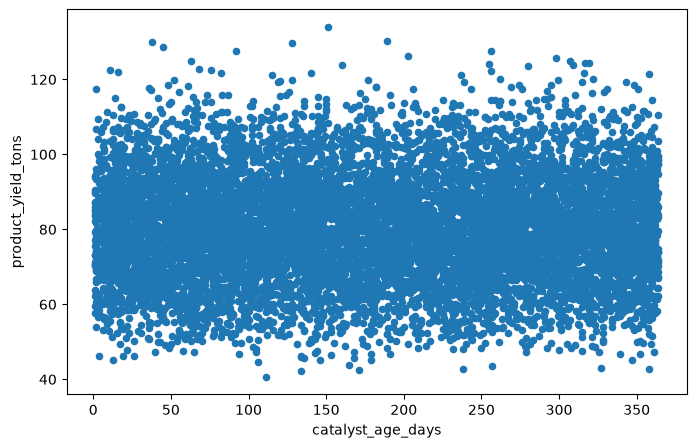

In [88]:
df_analysis.plot(
    x='catalyst_age_days',
    y='product_yield_tons',
    kind='scatter',
    figsize=(8,5)
)

Catalyst - Wise Aging Effect

In [89]:
df_analysis.groupby('catalyst_type').apply(
    lambda x: x['catalyst_age_days'].corr(x['product_yield_tons'])
)

catalyst_type
COBALT_PREMIUM_Z2   -0.003031
IRON_STANDARD_V5     0.018652
PLATINUM_BASE_X1     0.008241
dtype: float64

Catalyst Age vs Energy Intensity

In [90]:
df_analysis[
    ['catalyst_age_days', 'energy_intensity']
].corr()

,catalyst_age_days,energy_intensity
catalyst_age_days,1.000000,0.030679
energy_intensity,0.030679,1.000000


<Axes: xlabel='catalyst_age_days', ylabel='energy_intensity'>

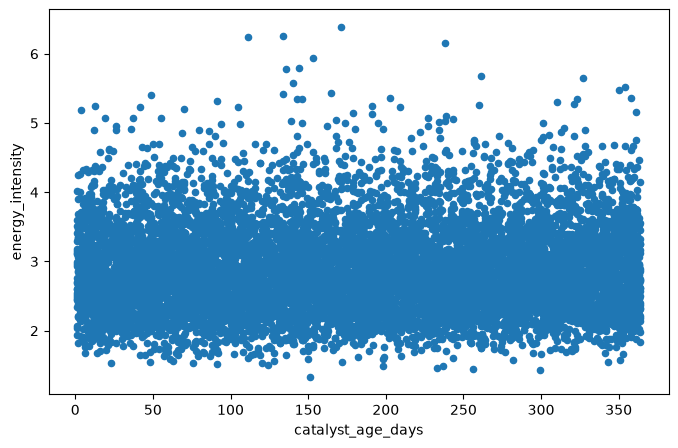

In [91]:
df_analysis.plot(
    x='catalyst_age_days',
    y='energy_intensity',
    kind='scatter',
    figsize=(8,5)
)

Catalyst-wise aging + energy

In [92]:
df_analysis.groupby('catalyst_type').apply(
    lambda x: x['catalyst_age_days'].corr(x['energy_intensity'])
)

catalyst_type
COBALT_PREMIUM_Z2    0.036432
IRON_STANDARD_V5     0.040712
PLATINUM_BASE_X1     0.015548
dtype: float64

RESULTS: Catalyst aging does not show a meaningful linear relationship with either product yield or energy intensity, either overall or within individual catalyst types. This suggests that catalyst age is not a major performance driver in the observed dataset

## **'Analysis 4 — Operating Conditions vs Yield'**

In [93]:
df_analysis[
    [
        'reactor_temp_c',
        'reactor_pressure_bar',
        'feedstock_flow_m3h',
        'valve_opening_percent',
        'product_yield_tons'
    ]
].corr()['product_yield_tons'].sort_values(ascending=False)

product_yield_tons       1.000000
reactor_pressure_bar     0.778641
feedstock_flow_m3h       0.624826
reactor_temp_c           0.013525
valve_opening_percent    0.004459
Name: product_yield_tons, dtype: float64

Reactor pressure shows a strong positive association with product yield, indicating that higher pressure levels are generally associated with higher production output..Temperature aur valve opening ka yield ke saath almost no linear association hai.

Pressure Scatter Plot

<Axes: xlabel='reactor_pressure_bar', ylabel='product_yield_tons'>

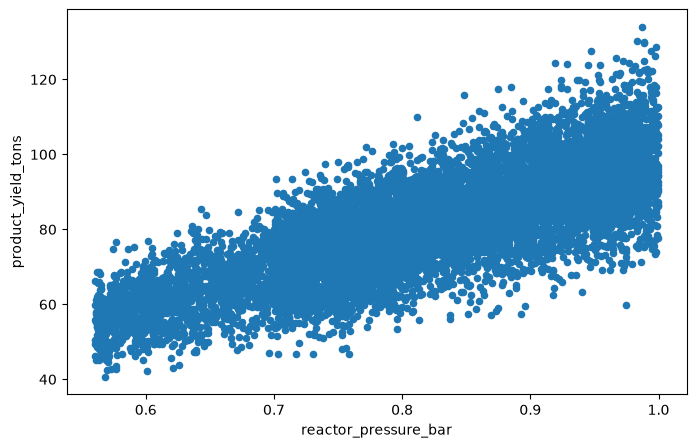

In [94]:
df_analysis.plot(
    x='reactor_pressure_bar',
    y='product_yield_tons',
    kind='scatter',
    figsize=(8,5)
)

feedstock flow vs yield

<Axes: xlabel='feedstock_flow_m3h', ylabel='product_yield_tons'>

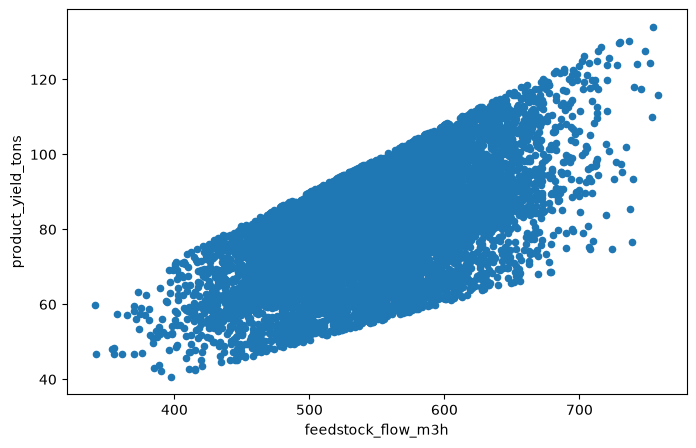

In [95]:
df_analysis.plot(
    x='feedstock_flow_m3h',
    y='product_yield_tons',
    kind='scatter',
    figsize=(8,5)
)

Feedstock flow shows a moderately strong positive association with product yield, indicating that higher feedstock flow is generally associated with higher production output.

Temperature vs Yield

<Axes: xlabel='reactor_temp_c', ylabel='product_yield_tons'>

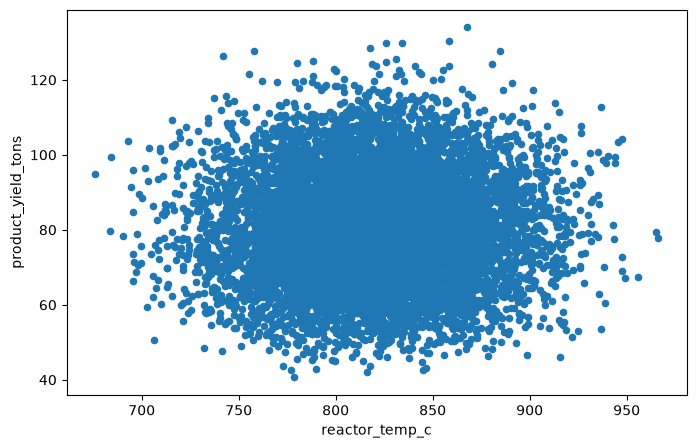

In [96]:
df_analysis.plot(
    x='reactor_temp_c',
    y='product_yield_tons',
    kind='scatter',
    figsize=(8,5)
)

Reactor temperature shows no clear linear relationship with product yield. The scatter plot forms a dense, roughly circular cloud, indicating that changes in temperature are not systematically associated with changes in yield in the observed data.

Valve opening vs yield

<Axes: xlabel='valve_opening_percent', ylabel='product_yield_tons'>

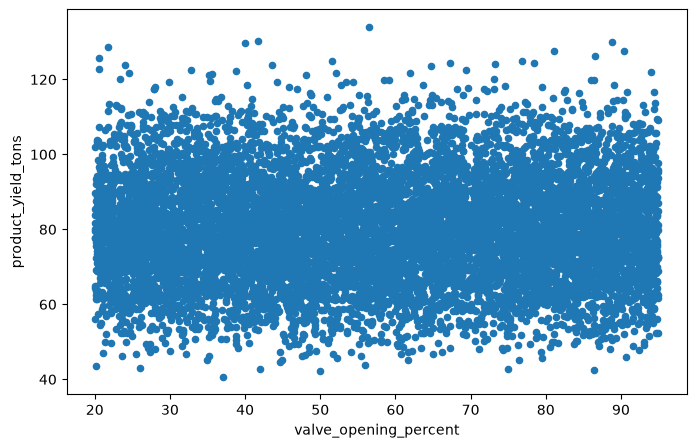

In [97]:
df_analysis.plot(
    x='valve_opening_percent',
    y='product_yield_tons',
    kind='scatter',
    figsize=(8,5)
)

Valve opening shows no clear linear relationship with product yield in the observed data.

## **'Analysis 5 — Energy Intensity'**


In [98]:
df_analysis['product_yield_tons'].corr(
    df_analysis['energy_intensity']
)

np.float64(-0.8192238244825679)

RESULT: Product yield shows a strong negative association with energy intensity (r = −0.819), indicating that higher production output is generally associated with lower energy intensity. This suggests that higher-yield operating conditions tend to be more energy-efficient in the observed dataset.

<Axes: xlabel='product_yield_tons', ylabel='energy_intensity'>

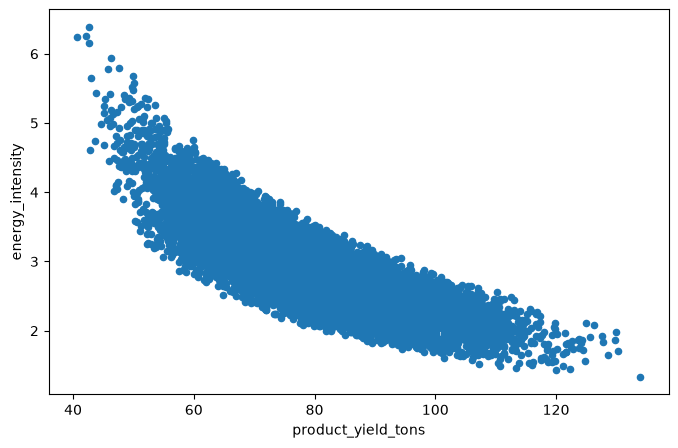

In [99]:
df_analysis.plot(
    x='product_yield_tons',
    y='energy_intensity',
    kind='scatter',
    figsize=(8,5)
)


In [100]:
df_analysis[
    [
        'electricity_mwh',
        'natural_gas_m3h',
        'steam_tons_h',
        'product_yield_tons'
    ]
].corr()['product_yield_tons'].sort_values(ascending=False)

product_yield_tons    1.000000
natural_gas_m3h       0.019438
electricity_mwh      -0.006244
steam_tons_h         -0.016729
Name: product_yield_tons, dtype: float64

Individual utility variables show almost no linear association with product yield, suggesting that production output is not strongly related to any single energy source in isolation. However, overall energy intensity shows a strong negative association with yield, indicating that the combined energy efficiency measure provides a more meaningful view of production performance.

Unit-wise Energy Efficiency

In [101]:
unit_energy = df_analysis.groupby('unit_name')['energy_intensity'].agg(
    ['mean', 'min', 'max', 'std']
)

unit_energy

,mean,min,max,std
unit_name,,,,
AMMONIA_UNIT_02,2.886437,1.508750,6.245976,0.637290
ETHYLENE_PLANT_01,2.882271,1.453450,5.584611,0.617830
METHANOL_COMPLEX_03,2.887044,1.331305,6.386947,0.620478


Among the three units, Ethylene Plant 01 shows the highest average product yield while also having the lowest average energy intensity. However, the differences in energy intensity across units are small, indicating broadly similar energy efficiency.

Production + Efficiency together


In [102]:
unit_performance = df_analysis.groupby('unit_name').agg(
    mean_yield=('product_yield_tons', 'mean'),
    mean_energy_intensity=('energy_intensity', 'mean')
)

unit_performance

,mean_yield,mean_energy_intensity
unit_name,,
AMMONIA_UNIT_02,80.257999,2.886437
ETHYLENE_PLANT_01,80.382193,2.882271
METHANOL_COMPLEX_03,80.004991,2.887044


RESULTS: 
Product yield shows a strong negative association with energy intensity (r = −0.819), indicating that higher-yield observations are generally associated with better energy efficiency. Individual utility variables show almost no direct linear relationship with yield. At the unit level, Ethylene Plant 01 achieves the highest average yield while maintaining the lowest average energy intensity, although the differences across units are relatively small.

## **'Analysis 6 — Unit Performance '**

Unit + Vibration


In [103]:
unit_vibration = df_analysis.groupby('unit_name')['vibration_level_mm_s'].agg(
    ['mean', 'min', 'max', 'std']
).sort_values('mean')

unit_vibration

,mean,min,max,std
unit_name,,,,
ETHYLENE_PLANT_01,4.408893,0.501166,8.496871,2.275798
METHANOL_COMPLEX_03,4.502459,0.501324,8.499197,2.320913
AMMONIA_UNIT_02,4.515033,0.500819,8.498499,2.326833


No such effect of unit wise vibration

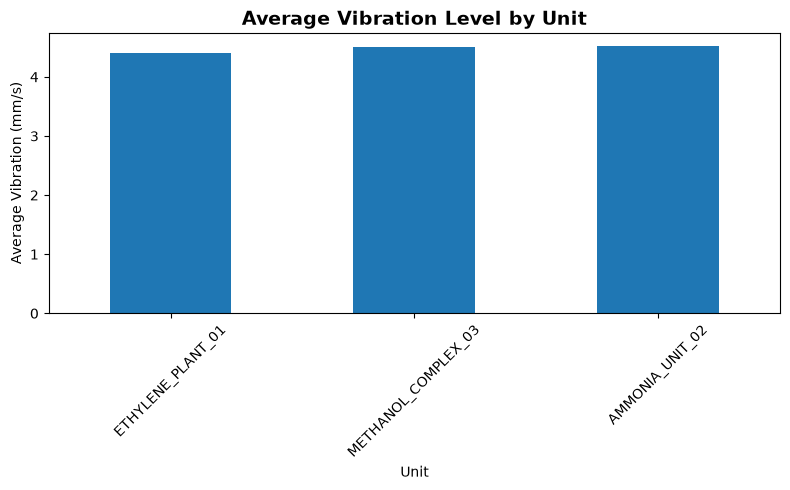

In [104]:
plt.figure(figsize=(8,5))

unit_vibration['mean'].plot(kind='bar')

plt.xlabel('Unit')
plt.ylabel('Average Vibration (mm/s)')
plt.title('Average Vibration Level by Unit', fontsize=14, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Unit +Sensor Health

In [105]:
unit_sensor = df_analysis.groupby('unit_name')['sensor_health_index'].agg(
    ['mean', 'min', 'max', 'std']
).sort_values('mean', ascending=False)

unit_sensor

,mean,min,max,std
unit_name,,,,
AMMONIA_UNIT_02,32.088782,20.668281,41.240782,2.937633
ETHYLENE_PLANT_01,31.965234,21.587030,43.580267,3.086329
METHANOL_COMPLEX_03,31.902644,21.527101,41.910611,2.965362


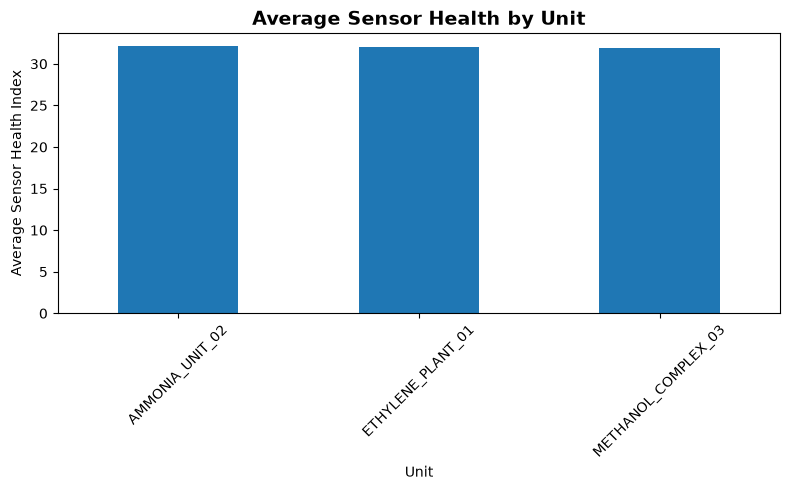

In [106]:
plt.figure(figsize=(8,5))

unit_sensor['mean'].plot(kind='bar')

plt.xlabel('Unit')
plt.ylabel('Average Sensor Health Index')
plt.title('Average Sensor Health by Unit', fontsize=14, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **'Analysis 7 — Equipment Health '**

Vibration vs Yield

In [107]:
df_analysis['vibration_level_mm_s'].corr(
    df_analysis['product_yield_tons']
)

np.float64(-0.3812095758650931)

Vibration level shows a moderate negative association with product yield (r = −0.381), indicating that higher equipment vibration is generally associated with lower production output.

Vibration vs Energy Intensity


In [108]:
df_analysis['vibration_level_mm_s'].corr(
    df_analysis['energy_intensity']
)

np.float64(0.33694765114089353)

Increase in vibration tends to increase in energy intensity

Sensor Health → Yield

In [109]:
df_analysis['sensor_health_index'].corr(
    df_analysis['product_yield_tons']
)

np.float64(-0.008076761054128858)

No Relationship

Sensor Health → Energy Intensity

In [110]:
df_analysis['sensor_health_index'].corr(
    df_analysis['energy_intensity']
)

np.float64(0.019653458583820636)

No relationship

## **'Analysis 8 - Anomaly Detection'**

In [111]:
Q1 = df_analysis[
    ['reactor_temp_c', 'reactor_pressure_bar',
     'vibration_level_mm_s', 'sensor_health_index',
     'energy_intensity', 'product_yield_tons']
].quantile(0.25)

Q3 = df_analysis[
    ['reactor_temp_c', 'reactor_pressure_bar',
     'vibration_level_mm_s', 'sensor_health_index',
     'energy_intensity', 'product_yield_tons']
].quantile(0.75)

IQR = Q3 - Q1

anomalies = (
    (df_analysis[
        ['reactor_temp_c', 'reactor_pressure_bar',
         'vibration_level_mm_s', 'sensor_health_index',
         'energy_intensity', 'product_yield_tons']
    ] < (Q1 - 1.5 * IQR)) |
    (df_analysis[
        ['reactor_temp_c', 'reactor_pressure_bar',
         'vibration_level_mm_s', 'sensor_health_index',
         'energy_intensity', 'product_yield_tons']
    ] > (Q3 + 1.5 * IQR))
)

anomalies.sum()

reactor_temp_c           88
reactor_pressure_bar      0
vibration_level_mm_s      0
sensor_health_index      63
energy_intensity        152
product_yield_tons       40
dtype: int64

In [112]:
anomaly_rows = df_analysis[anomalies.any(axis=1)]

anomaly_rows[
    ['reactor_temp_c',
     'reactor_pressure_bar',
     'vibration_level_mm_s',
     'sensor_health_index',
     'energy_intensity',
     'product_yield_tons']
].describe()

,reactor_temp_c,reactor_pressure_bar,vibration_level_mm_s,sensor_health_index,energy_intensity,product_yield_tons
count,338.000000,338.000000,338.000000,338.000000,338.000000,338.000000
mean,818.759180,0.749720,5.337288,32.239022,3.626250,73.321373
std,68.884853,0.144054,2.437404,4.708520,1.277785,24.873488
min,675.824163,0.560232,0.511380,20.668281,1.331305,40.620501
25%,779.825662,0.610439,3.217922,29.585171,2.411942,52.102736
50%,820.494204,0.731081,6.210555,32.054378,3.482513,67.060014
75%,858.210918,0.880604,7.417418,34.844038,4.699623,88.506068
max,966.361150,0.997868,8.493493,43.580267,6.386947,133.977440


The anomalous observations show lower average production yield (73.3 tons vs 80.2 tons overall) and higher average energy intensity (3.63 vs 2.89 overall), indicating that unusual operating conditions are associated with poorer production performance and energy efficiency.

In [113]:
anomaly_details = anomalies.copy()

anomaly_details['anomalous_variables'] = anomalies.apply(
    lambda row: ', '.join(row.index[row]),
    axis=1
)

anomaly_details = anomaly_details[
    anomaly_details['anomalous_variables'] != ''
]

anomaly_details = anomaly_details[
    ['anomalous_variables']
].reset_index()

anomaly_details.columns = ['row_index', 'anomalous_variable']

anomaly_details

,row_index,anomalous_variable
0,37,reactor_temp_c
1,67,energy_intensity
2,79,sensor_health_index
3,116,energy_intensity
4,132,reactor_temp_c
...,...,...
333,9878,reactor_temp_c
334,9896,reactor_temp_c
335,9898,energy_intensity
336,9922,product_yield_tons


## **'Pressure → Yield: Complete Analysis'**

In [114]:
# Kya kisi particular pressure range mein yield best hai?

pressure_bins = pd.cut(
    df_analysis['reactor_pressure_bar'],
    bins=5
)

pressure_yield = df_analysis.groupby(
    pressure_bins,
    observed=True
)['product_yield_tons'].agg(['count', 'mean', 'std'])

pressure_yield





,count,mean,std
reactor_pressure_bar,,,
"(0.56, 0.648]",875,59.977939,7.141413
"(0.648, 0.736]",1808,69.793622,7.800962
"(0.736, 0.824]",2892,76.975561,8.691931
"(0.824, 0.912]",2178,86.209719,9.632230
"(0.912, 1.0]",2246,94.851267,10.823284


In [115]:
# Same pressure par yield variation

df_analysis.groupby(
    pressure_bins,
    observed=True
)['product_yield_tons'].agg(['mean', 'min', 'max', 'std'])

,mean,min,max,std
reactor_pressure_bar,,,,
"(0.56, 0.648]",59.977939,40.620501,85.373136,7.141413
"(0.648, 0.736]",69.793622,46.692954,95.344284,7.800962
"(0.736, 0.824]",76.975561,46.678686,110.101271,8.691931
"(0.824, 0.912]",86.209719,55.975740,117.960017,9.632230
"(0.912, 1.0]",94.851267,59.821492,133.977440,10.823284


In [116]:
# Other factors ka comparison

df_analysis.groupby(pressure_bins, observed=True)[
    [
        'product_yield_tons',
        'reactor_temp_c',
        'feedstock_flow_m3h',
        'vibration_level_mm_s'
    ]
].mean()

,product_yield_tons,reactor_temp_c,feedstock_flow_m3h,vibration_level_mm_s
reactor_pressure_bar,,,,
"(0.56, 0.648]",59.977939,817.438701,551.593448,7.529131
"(0.648, 0.736]",69.793622,819.662313,549.885469,5.487439
"(0.736, 0.824]",76.975561,819.173157,549.958746,4.401711
"(0.824, 0.912]",86.209719,819.951103,551.534932,3.505080
"(0.912, 1.0]",94.851267,819.925261,551.243917,3.506344


In [117]:
# Vibrations on High vs Low Yield

# Required libraries
import numpy as np
import pandas as pd


# 1. Divide reactor pressure into 5 ranges
df_analysis['pressure_range'] = pd.cut(
    df_analysis['reactor_pressure_bar'],
    bins=5
)


# 2. Find the median yield separately within each pressure range
#    This will be used to divide observations into High Yield and Low Yield
pressure_median = (
    df_analysis
    .groupby('pressure_range', observed=True)['product_yield_tons']
    .transform('median')
)


# 3. Classify each observation as High Yield or Low Yield
#    High Yield = yield >= median of its own pressure range
#    Low Yield  = yield < median of its own pressure range
df_analysis['yield_group'] = np.where(
    df_analysis['product_yield_tons'] >= pressure_median,
    'High Yield',
    'Low Yield'
)


# 4. Compare High-Yield and Low-Yield observations
#    within the SAME pressure range
#    We compare yield, vibration, temperature and feedstock flow
high_low_comparison = (
    df_analysis
    .groupby(
        ['pressure_range', 'yield_group'],
        observed=True
    )[
        [
            'product_yield_tons',
            'vibration_level_mm_s',
            'reactor_temp_c',
            'feedstock_flow_m3h'
        ]
    ]
    .mean()
    .round(2)
)


# 5. Display the result
high_low_comparison

product_yield_tons  vibration_level_mm_s  \
pressure_range yield_group                                             
(0.56, 0.648]  High Yield                65.71                  7.55   
               Low Yield                 54.23                  7.50   
(0.648, 0.736] High Yield                76.02                  5.22   
               Low Yield                 63.56                  5.76   
(0.736, 0.824] High Yield                83.94                  4.31   
               Low Yield                 70.01                  4.50   
(0.824, 0.912] High Yield                93.87                  3.48   
               Low Yield                 78.55                  3.53   
(0.912, 1.0]   High Yield               103.50                  3.50   
               Low Yield                 86.20                  3.52   

                            reactor_temp_c  feedstock_flow_m3h  
pressure_range yield_group                                      
(0.56, 0.648]  High Yield           817.35              597.91  
               Low Yield            817.53              505.17  
(0.648, 0.736] High Yield           821.36              594.15  
               Low Yield            817.97              505.62  
(0.736, 0.824] High Yield           819.30              595.93  
               Low Yield            819.05              503.99  
(0.824, 0.912] High Yield           820.48              597.08  
               Low Yield            819.42              505.99  
(0.912, 1.0]   High Yield           819.23              599.38  
               Low Yield            820.62              503.11

Final Overall Conclusion


Reactor pressure is the strongest observed factor associated with product yield, showing a strong positive correlation (r = 0.779). Average yield increases consistently from 59.98 tons at 0.56–0.648 bar to 94.85 tons at 0.912–1.00 bar. However, substantial yield variation exists even within the same pressure range, indicating that pressure alone does not determine production yield.

The same-pressure High vs Low Yield analysis suggests that feedstock flow is a more important factor in explaining this variation, as high-yield observations consistently have higher feedstock flow. In contrast, reactor temperature remains relatively stable, while vibration shows little difference between high- and low-yield observations within the same pressure range. Therefore, vibration may be associated with the overall pressure–yield relationship but does not appear to be a major explanation for within-pressure yield variation.

Catalyst type and production unit show only small differences in average yield, whereas the morning shift consistently shows slightly higher performance. Overall, the data suggests that yield is primarily associated with reactor pressure and feedstock flow, while other factors such as temperature, vibration, catalyst type and unit have weaker observed effects. These are associations from historical data and should not be interpreted as proof of causation.

## **'Feedstock → Yield: Complete Analysis'**

Feedstock Flow vs Yield Correlation: 0.625


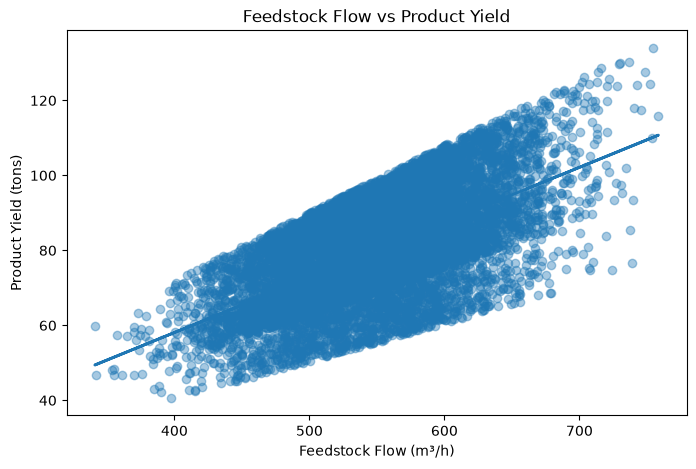

product_yield_tons       1.000
reactor_pressure_bar     0.779
feedstock_flow_m3h       0.625
reactor_temp_c           0.014
valve_opening_percent    0.004
sensor_health_index     -0.008
vibration_level_mm_s    -0.381
Name: product_yield_tons, dtype: float64

In [118]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Feedstock Flow → Yield: Correlation
# ============================================================

correlation = df_analysis[
    ['feedstock_flow_m3h', 'product_yield_tons']
].corr().loc['feedstock_flow_m3h', 'product_yield_tons']

print("Feedstock Flow vs Yield Correlation:", round(correlation, 3))


# ============================================================
# 2. Check whether the relationship looks linear
#    Scatter plot + linear trendline
# ============================================================

x = df_analysis['feedstock_flow_m3h']
y = df_analysis['product_yield_tons']

# Calculate linear trendline
slope, intercept = np.polyfit(x, y, 1)

# Predicted yield from the linear relationship
y_pred = slope * x + intercept

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.4)

plt.plot(
    x,
    y_pred,
    linewidth=2
)

plt.xlabel('Feedstock Flow (m³/h)')
plt.ylabel('Product Yield (tons)')
plt.title('Feedstock Flow vs Product Yield')

plt.show()


# ============================================================
# 3. Divide feedstock flow into 5 ranges
#    This helps check whether yield keeps increasing
#    or starts to plateau at higher flow.
# ============================================================

df_analysis['feedstock_range'] = pd.cut(
    df_analysis['feedstock_flow_m3h'],
    bins=5
)


# Calculate average yield for each flow range
flow_yield_summary = (
    df_analysis
    .groupby('feedstock_range', observed=True)['product_yield_tons']
    .agg(['count', 'mean', 'min', 'max', 'std'])
    .round(2)
)

flow_yield_summary


# ============================================================
# 4. Check whether yield plateaus
# ============================================================

flow_yield_mean = (
    df_analysis
    .groupby('feedstock_range', observed=True)['product_yield_tons']
    .mean()
    .round(2)
)

flow_yield_mean


# ============================================================
# 5. Same feedstock flow par High vs Low Yield compare karo
#    Median of each flow range is used to classify observations.
# ============================================================

flow_median = (
    df_analysis
    .groupby('feedstock_range', observed=True)['product_yield_tons']
    .transform('median')
)

df_analysis['flow_yield_group'] = np.where(
    df_analysis['product_yield_tons'] >= flow_median,
    'High Yield',
    'Low Yield'
)


# ============================================================
# 6. Within the same feedstock range:
#    Compare other operating conditions
# ============================================================

high_low_flow = (
    df_analysis
    .groupby(
        ['feedstock_range', 'flow_yield_group'],
        observed=True
    )[
        [
            'product_yield_tons',
            'reactor_pressure_bar',
            'reactor_temp_c',
            'vibration_level_mm_s',
            'sensor_health_index',
            'valve_opening_percent'
        ]
    ]
    .mean()
    .round(2)
)

high_low_flow


# ============================================================
# 7. Correlation of other operating variables with yield
#    This helps identify possible factors behind
#    high/low yield at similar feedstock flow.
# ============================================================

other_variables = [
    'feedstock_flow_m3h',
    'reactor_pressure_bar',
    'reactor_temp_c',
    'vibration_level_mm_s',
    'sensor_health_index',
    'valve_opening_percent'
]

correlation_with_yield = (
    df_analysis[other_variables + ['product_yield_tons']]
    .corr()['product_yield_tons']
    .sort_values(ascending=False)
    .round(3)
)

correlation_with_yield

In [119]:
flow_yield_summary

,count,mean,min,max,std
feedstock_range,,,,,
"(340.616, 424.53]",156,58.94,40.62,75.60,8.71
"(424.53, 508.026]",2233,69.54,44.61,91.06,10.13
"(508.026, 591.522]",5108,79.96,51.82,105.92,11.23
"(591.522, 675.018]",2328,90.74,59.88,120.20,12.81
"(675.018, 758.514]",174,103.13,68.61,133.98,15.40


In [120]:
high_low_flow

product_yield_tons  reactor_pressure_bar  \
feedstock_range    flow_yield_group                                             
(340.616, 424.53]  High Yield                     66.05                  0.90   
                   Low Yield                      51.83                  0.72   
(424.53, 508.026]  High Yield                     77.95                  0.90   
                   Low Yield                      61.12                  0.72   
(508.026, 591.522] High Yield                     89.26                  0.90   
                   Low Yield                      70.65                  0.72   
(591.522, 675.018] High Yield                    101.41                  0.90   
                   Low Yield                      80.08                  0.72   
(675.018, 758.514] High Yield                    116.11                  0.92   
                   Low Yield                      90.15                  0.72   

                                     reactor_temp_c  vibration_level_mm_s  \
feedstock_range    flow_yield_group                                         
(340.616, 424.53]  High Yield                824.73                  3.98   
                   Low Yield                 821.20                  4.88   
(424.53, 508.026]  High Yield                818.16                  3.60   
                   Low Yield                 818.16                  5.42   
(508.026, 591.522] High Yield                820.57                  3.63   
                   Low Yield                 819.52                  5.30   
(591.522, 675.018] High Yield                819.48                  3.59   
                   Low Yield                 818.43                  5.37   
(675.018, 758.514] High Yield                821.30                  3.46   
                   Low Yield                 822.49                  5.45   

                                     sensor_health_index  \
feedstock_range    flow_yield_group                        
(340.616, 424.53]  High Yield                      32.73   
                   Low Yield                       32.02   
(424.53, 508.026]  High Yield                      31.92   
                   Low Yield                       32.04   
(508.026, 591.522] High Yield                      31.95   
                   Low Yield                       31.99   
(591.522, 675.018] High Yield                      32.01   
                   Low Yield                       32.01   
(675.018, 758.514] High Yield                      31.65   
                   Low Yield                       32.15   

                                     valve_opening_percent  
feedstock_range    flow_yield_group                         
(340.616, 424.53]  High Yield                        61.33  
                   Low Yield                         60.46  
(424.53, 508.026]  High Yield                        57.88  
                   Low Yield                         57.53  
(508.026, 591.522] High Yield                        57.95  
                   Low Yield                         57.37  
(591.522, 675.018] High Yield                        57.73  
                   Low Yield                         57.23  
(675.018, 758.514] High Yield                        59.05  
                   Low Yield                         59.05

Objective: Examine the relationship between feedstock flow and product yield and identify factors explaining yield variation at similar flow levels.

Feedstock flow and yield show a positive correlation (r = 0.625).
Average yield increases consistently with increasing flow:
58.94 → 69.54 → 79.96 → 90.74 → 103.13 tons.
Scatter plot shows an approximately linear upward relationship over the observed range.
No clear plateau is observed up to approximately 759 m³/h.
However, substantial variation exists within each flow range, indicating that feedstock flow alone does not determine yield.
Within the same feedstock-flow range, higher-yield observations consistently have higher reactor pressure (~0.90 bar) compared with lower-yield observations (~0.72 bar).
Higher-yield observations also show lower vibration (~3.5–4.0 mm/s) compared with low-yield observations (~4.9–5.5 mm/s).
Temperature, sensor health and valve opening show relatively small differences between High and Low Yield groups.
Therefore, feedstock flow is an important positive factor, but reactor pressure appears to be a major additional factor explaining why yield differs even at similar feedstock flow.
These findings represent associations in historical data and do not establish causation.

## **'Shift → Yield: Why is Morning better?'**

In [121]:
# WHY 2: Shift → Yield

shift_why = df_analysis.groupby('shift').agg(
    yield_mean=('product_yield_tons', 'mean'),
    pressure_mean=('reactor_pressure_bar', 'mean'),
    flow_mean=('feedstock_flow_m3h', 'mean'),
    temp_mean=('reactor_temp_c', 'mean'),
    vibration_mean=('vibration_level_mm_s', 'mean'),
    sensor_health_mean=('sensor_health_index', 'mean'),
    energy_mean=('energy_intensity', 'mean'),
    count=('product_yield_tons', 'count')
).sort_values('yield_mean', ascending=False)

print("Shift → Yield WHY Analysis")
display(shift_why)

print("\nDifference from best shift:")
best_shift_yield = shift_why['yield_mean'].max()

shift_why['yield_difference_from_best'] = (
    best_shift_yield - shift_why['yield_mean']
)

display(shift_why)

Shift → Yield WHY Analysis


,yield_mean,pressure_mean,flow_mean,temp_mean,vibration_mean,sensor_health_mean,energy_mean,count
shift,,,,,,,,
Morning,80.599896,0.812868,550.849198,819.116765,4.419981,31.972769,2.876563,3333
Night,80.042066,0.808221,550.157770,819.811481,4.470507,32.071185,2.886723,3334
Evening,80.006573,0.806495,551.154990,819.416290,4.535376,31.913779,2.892437,3332



Difference from best shift:


,yield_mean,pressure_mean,flow_mean,temp_mean,vibration_mean,sensor_health_mean,energy_mean,count,yield_difference_from_best
shift,,,,,,,,,
Morning,80.599896,0.812868,550.849198,819.116765,4.419981,31.972769,2.876563,3333,0.000000
Night,80.042066,0.808221,550.157770,819.811481,4.470507,32.071185,2.886723,3334,0.557831
Evening,80.006573,0.806495,551.154990,819.416290,4.535376,31.913779,2.892437,3332,0.593324


Morning shift has the highest yield, but the difference is small. Its slightly better performance coincides with marginally higher pressure, lower vibration, and lower energy intensity, suggesting a weak shift effect rather than a strong independent driver.

## **'Unit × Catalyst × Shift'**

In [122]:
# WHY 3: Unit × Catalyst × Shift → Actual Driver

# Overall individual effects
unit_effect = df_analysis.groupby('unit_name')['product_yield_tons'].mean()
catalyst_effect = df_analysis.groupby('catalyst_type')['product_yield_tons'].mean()
shift_effect = df_analysis.groupby('shift')['product_yield_tons'].mean()

# All combinations
combo = df_analysis.groupby(
    ['unit_name', 'catalyst_type', 'shift']
).agg(
    yield_mean=('product_yield_tons', 'mean'),
    pressure_mean=('reactor_pressure_bar', 'mean'),
    flow_mean=('feedstock_flow_m3h', 'mean'),
    temp_mean=('reactor_temp_c', 'mean'),
    vibration_mean=('vibration_level_mm_s', 'mean'),
    energy_mean=('energy_intensity', 'mean'),
    count=('product_yield_tons', 'count')
).reset_index().sort_values('yield_mean', ascending=False)

print("Individual Effects")
print("\nUnit:")
display(unit_effect.sort_values(ascending=False))

print("\nCatalyst:")
display(catalyst_effect.sort_values(ascending=False))

print("\nShift:")
display(shift_effect.sort_values(ascending=False))

print("\nBest 5 combinations:")
display(combo.head(5))

print("\nWorst 5 combinations:")
display(combo.tail(5))

Individual Effects

Unit:


unit_name
ETHYLENE_PLANT_01      80.382193
AMMONIA_UNIT_02        80.257999
METHANOL_COMPLEX_03    80.004991
Name: product_yield_tons, dtype: float64


Catalyst:


catalyst_type
IRON_STANDARD_V5     80.273495
COBALT_PREMIUM_Z2    80.273129
PLATINUM_BASE_X1     80.103755
Name: product_yield_tons, dtype: float64


Shift:


shift
Morning    80.599896
Night      80.042066
Evening    80.006573
Name: product_yield_tons, dtype: float64


Best 5 combinations:


,unit_name,catalyst_type,shift,yield_mean,pressure_mean,flow_mean,temp_mean,vibration_mean,energy_mean,count
25,METHANOL_COMPLEX_03,PLATINUM_BASE_X1,Morning,81.618834,0.815764,555.932681,818.926639,4.491786,2.853262,375
1,AMMONIA_UNIT_02,COBALT_PREMIUM_Z2,Morning,81.307548,0.818268,552.086023,818.456094,4.385599,2.866725,375
10,ETHYLENE_PLANT_01,COBALT_PREMIUM_Z2,Morning,81.164778,0.821118,549.313710,820.320103,4.215661,2.856451,403
4,AMMONIA_UNIT_02,IRON_STANDARD_V5,Morning,81.140472,0.816168,552.513477,817.855050,4.553976,2.841313,378
13,ETHYLENE_PLANT_01,IRON_STANDARD_V5,Morning,81.019283,0.817586,550.611773,821.468732,4.339549,2.860223,368



Worst 5 combinations:


,unit_name,catalyst_type,shift,yield_mean,pressure_mean,flow_mean,temp_mean,vibration_mean,energy_mean,count
22,METHANOL_COMPLEX_03,IRON_STANDARD_V5,Morning,79.337006,0.803961,548.342012,820.052349,4.532507,2.897392,348
3,AMMONIA_UNIT_02,IRON_STANDARD_V5,Evening,79.232996,0.797821,551.998278,817.501285,4.799985,2.932221,365
24,METHANOL_COMPLEX_03,PLATINUM_BASE_X1,Evening,78.825168,0.801696,546.701235,818.502142,4.533840,2.937076,369
26,METHANOL_COMPLEX_03,PLATINUM_BASE_X1,Night,78.775195,0.803443,544.569756,820.420060,4.650451,2.936922,372
2,AMMONIA_UNIT_02,COBALT_PREMIUM_Z2,Night,78.687138,0.799864,547.009398,823.564064,4.603536,2.927436,363


The best-performing combination was Methanol + Platinum + Morning (81.62 tons), while Ammonia + Cobalt + Night recorded the lowest yield (78.69 tons). However, the individual effects of unit and catalyst are very small: unit-level yield differs by only ~0.38 tons and catalyst-level yield by ~0.17 tons. Shift shows a somewhat larger but still modest difference (~0.59 tons), with Morning performing best. The best combination is also associated with slightly higher reactor pressure and feedstock flow, lower vibration, and lower energy intensity. Therefore, the observed combination-level difference appears to be driven more by operating conditions and shift than by catalyst type alone.

## **'Equipment Health: Why does higher vibration reduce yield and increase energy?'**

In [123]:
# WHY 4: Equipment Health → Yield & Energy

vibration_bins = pd.qcut(
    df_analysis['vibration_level_mm_s'],
    q=5,
    duplicates='drop'
)

equipment_why = df_analysis.groupby(
    vibration_bins,
    observed=True
).agg(
    yield_mean=('product_yield_tons', 'mean'),
    energy_mean=('energy_intensity', 'mean'),
    sensor_health_mean=('sensor_health_index', 'mean'),
    pressure_mean=('reactor_pressure_bar', 'mean'),
    flow_mean=('feedstock_flow_m3h', 'mean'),
    temp_mean=('reactor_temp_c', 'mean'),
    count=('product_yield_tons', 'count')
).reset_index()

print("Vibration → Equipment Health WHY Analysis")
display(equipment_why)

print("\nCorrelations with vibration:")
display(
    df_analysis[
        [
            'vibration_level_mm_s',
            'product_yield_tons',
            'energy_intensity',
            'sensor_health_index',
            'reactor_pressure_bar',
            'feedstock_flow_m3h'
        ]
    ].corr()['vibration_level_mm_s'].sort_values()
)

Vibration → Equipment Health WHY Analysis


,vibration_level_mm_s,yield_mean,energy_mean,sensor_health_mean,pressure_mean,flow_mean,temp_mean,count
0,"(0.5, 2.091]",84.074921,2.733972,31.975177,0.847914,550.696252,820.886095,2000
1,"(2.091, 3.648]",84.510062,2.718126,31.955318,0.851847,551.040974,818.533927,2000
2,"(3.648, 5.238]",84.525172,2.716333,31.962853,0.853872,550.051377,819.467709,1999
3,"(5.238, 6.874]",80.417694,2.868749,31.960276,0.811813,550.169181,819.633375,2000
4,"(6.874, 8.499]",67.555215,3.388936,32.075998,0.680550,551.644646,818.719995,2000



Correlations with vibration:


reactor_pressure_bar   -0.491830
product_yield_tons     -0.381210
feedstock_flow_m3h      0.002687
sensor_health_index     0.010814
energy_intensity        0.336948
vibration_level_mm_s    1.000000
Name: vibration_level_mm_s, dtype: float64

Equipment Health: Vibration has a nonlinear relationship with production performance. Yield remains relatively stable at low-to-moderate vibration levels (~84.1–84.5 tons), but declines sharply to 67.6 tons at the highest vibration range (6.87–8.50 mm/s). At the same time, energy intensity increases from 2.72 to 3.39, while reactor pressure decreases from 0.85 to 0.68 bar. Vibration is moderately negatively associated with yield (r = −0.381) and positively associated with energy intensity (r = 0.337), while its correlation with feedstock flow and sensor health is negligible. This suggests that high vibration is associated with deteriorated process performance and energy efficiency, rather than simply reflecting poor sensor health. However, these are historical associations and do not establish causation.

## **'Energy Efficiency: Why is energy intensity high/low?'**

In [124]:
# WHY 5: Energy Efficiency → Why is Energy Intensity High/Low?

yield_median = df_analysis['product_yield_tons'].median()
energy_median = df_analysis['energy_intensity'].median()

df_analysis['performance_category'] = np.select(
    [
        (df_analysis['product_yield_tons'] >= yield_median) &
        (df_analysis['energy_intensity'] <= energy_median),

        (df_analysis['product_yield_tons'] >= yield_median) &
        (df_analysis['energy_intensity'] > energy_median),

        (df_analysis['product_yield_tons'] < yield_median) &
        (df_analysis['energy_intensity'] <= energy_median),

        (df_analysis['product_yield_tons'] < yield_median) &
        (df_analysis['energy_intensity'] > energy_median)
    ],
    [
        'High Yield + Low Energy',
        'High Yield + High Energy',
        'Low Yield + Low Energy',
        'Low Yield + High Energy'
    ],
    default='Unknown'
)

energy_why = df_analysis.groupby(
    'performance_category'
).agg(
    yield_mean=('product_yield_tons', 'mean'),
    energy_mean=('energy_intensity', 'mean'),
    pressure_mean=('reactor_pressure_bar', 'mean'),
    flow_mean=('feedstock_flow_m3h', 'mean'),
    temp_mean=('reactor_temp_c', 'mean'),
    vibration_mean=('vibration_level_mm_s', 'mean'),
    sensor_health_mean=('sensor_health_index', 'mean'),
    count=('product_yield_tons', 'count')
).sort_values('yield_mean', ascending=False)

print("Energy Efficiency WHY Analysis")
display(energy_why)

Energy Efficiency WHY Analysis


,yield_mean,energy_mean,pressure_mean,flow_mean,temp_mean,vibration_mean,sensor_health_mean,count
performance_category,,,,,,,,
High Yield + Low Energy,93.132982,2.352446,0.890227,583.000314,820.089482,3.720908,31.948013,4089
High Yield + High Energy,84.662169,3.008287,0.842481,562.315144,820.230348,3.898486,31.981877,911
Low Yield + Low Energy,74.579000,2.595898,0.777762,536.971525,819.588985,4.482545,31.761216,911
Low Yield + High Energy,67.561676,3.455224,0.727730,518.913005,818.601132,5.356759,32.074829,4088


Energy Efficiency: The data shows that high production does not necessarily require high energy intensity. The best-performing state, High Yield + Low Energy, achieves an average yield of 93.13 tons at only 2.35 energy intensity, while the worst state, Low Yield + High Energy, produces only 67.56 tons at 3.46 energy intensity. The high-yield, low-energy state is associated with higher reactor pressure (0.89 bar), higher feedstock flow (583 m³/h), and lower vibration (3.72 mm/s), whereas the low-yield, high-energy state shows lower pressure and flow and substantially higher vibration (5.36 mm/s). Sensor health remains similar across these groups, suggesting it is not a major differentiating factor. Overall, the results indicate that efficient operation is associated with maintaining favourable pressure and feedstock flow while avoiding high-vibration conditions. These are historical associations and do not establish causation.

Overall project conclusion:

Product yield is primarily associated with reactor pressure and feedstock flow, while high vibration is associated with deteriorating yield and energy efficiency. Unit and catalyst effects are comparatively small, and shift differences are modest. The most favourable operating state combines higher pressure and feedstock flow with controlled vibration, enabling high production without proportionally high energy intensity.

Despite monitoring multiple process, equipment, catalyst and operational variables, only a small subset shows strong association with production performance.”

## **'ANOVA/t-test (Changes/Insights Observed are real or a matter of chance)'**

In [125]:
!pip install scipy

In [126]:
from scipy import stats

# ==============================
# 1. Catalyst-wise ANOVA
# ==============================

iron = df_analysis[
    df_analysis['catalyst_type'] == 'IRON_STANDARD_V5'
]['product_yield_tons']

cobalt = df_analysis[
    df_analysis['catalyst_type'] == 'COBALT_PREMIUM_Z2'
]['product_yield_tons']

platinum = df_analysis[
    df_analysis['catalyst_type'] == 'PLATINUM_BASE_X1'
]['product_yield_tons']

f_stat, p_value = stats.f_oneway(iron, cobalt, platinum)

print("Catalyst ANOVA")
print("F-statistic:", f_stat)
print("p-value:", p_value)


# ==============================
# 2. Unit-wise ANOVA
# ==============================

ethylene = df_analysis[
    df_analysis['unit_name'] == 'ETHYLENE_PLANT_01'
]['product_yield_tons']

ammonia = df_analysis[
    df_analysis['unit_name'] == 'AMMONIA_UNIT_02'
]['product_yield_tons']

methanol = df_analysis[
    df_analysis['unit_name'] == 'METHANOL_COMPLEX_03'
]['product_yield_tons']

f_stat2, p_value2 = stats.f_oneway(
    ethylene,
    ammonia,
    methanol
)

print("\nUnit ANOVA")
print("F-statistic:", f_stat2)
print("p-value:", p_value2)


# ==============================
# 3. Shift-wise ANOVA
# ==============================

morning = df_analysis[
    df_analysis['shift'] == 'Morning'
]['product_yield_tons']

evening = df_analysis[
    df_analysis['shift'] == 'Evening'
]['product_yield_tons']

night = df_analysis[
    df_analysis['shift'] == 'Night'
]['product_yield_tons']

f_stat3, p_value3 = stats.f_oneway(
    morning,
    evening,
    night
)

print("\nShift ANOVA")
print("F-statistic:", f_stat3)
print("p-value:", p_value3)

Catalyst ANOVA
F-statistic: 0.16192349139000642
p-value: 0.8505085039117385

Unit ANOVA
F-statistic: 0.6188478772659813
p-value: 0.5385852052764367

Shift ANOVA
F-statistic: 1.861874316013322
p-value: 0.1554350054996443


In [127]:
from scipy.stats import pearsonr

# Pressure vs Yield
r, p = pearsonr(
    df_analysis['reactor_pressure_bar'],
    df_analysis['product_yield_tons']
)

print("Pressure vs Yield — r:", r, "p:", p)


# Feedstock Flow vs Yield
r2, p2 = pearsonr(
    df_analysis['feedstock_flow_m3h'],
    df_analysis['product_yield_tons']
)

print("Flow vs Yield — r:", r2, "p:", p2)


# Vibration vs Yield
r3, p3 = pearsonr(
    df_analysis['vibration_level_mm_s'],
    df_analysis['product_yield_tons']
)

print("Vibration vs Yield — r:", r3, "p:", p3)


# Energy Intensity vs Yield
r4, p4 = pearsonr(
    df_analysis['energy_intensity'],
    df_analysis['product_yield_tons']
)

print("Energy Intensity vs Yield — r:", r4, "p:", p4)

Pressure vs Yield — r: 0.7786408048060943 p: 0.0
Flow vs Yield — r: 0.6248256699087256 p: 0.0
Vibration vs Yield — r: -0.38120957586509335 p: 0.0
Energy Intensity vs Yield — r: -0.8192238244825679 p: 0.0


| Factor               | Type        | Descriptive Result                                                    | Inferential Test    | Test Result                | Statistically Significant? |
| -------------------- | ----------- | --------------------------------------------------------------------- | ------------------- | -------------------------- | -------------------------- |
| **Reactor Pressure** | Continuous  | r = 0.779 (strong positive)                                           | Pearson correlation | p < 0.001                  |  Yes                      |
| **Feedstock Flow**   | Continuous  | r = 0.625 (moderate-strong positive)                                  | Pearson correlation | p < 0.001                  |  Yes                      |
| **Vibration Level**  | Continuous  | r = −0.381 (moderate negative)                                        | Pearson correlation | p < 0.001                  |  Yes                      |
| **Energy Intensity** | Continuous  | r = −0.819 (strong negative)                                          | Pearson correlation | p < 0.001                  |  Yes                      |
| **Catalyst Type**    | Categorical | Mean diff ≈ 0.17 tons (Iron 80.27, Cobalt 80.27, Platinum 80.10)      | One-way ANOVA       | F = 0.162, p = 0.851       |  No                       |
| **Production Unit**  | Categorical | Mean diff ≈ 0.38 tons (Ethylene 80.38, Ammonia 80.26, Methanol 80.00) | One-way ANOVA       | F = 0.619, p = 0.539       |  No                       |
| **Shift**            | Categorical | Mean diff ≈ 0.59 tons (Morning 80.60, Night 80.04, Evening 80.01)     | One-way ANOVA       | F = 1.862, p = 0.155       |  No                       |
| **Catalyst Age**     | Continuous  | r = 0.008 with yield (negligible)                                     | Pearson correlation | No meaningful relationship |  No                       |


RESULTS:

Descriptive Statistics Results:

Descriptive analysis showed that reactor pressure, feedstock flow, vibration level, and energy intensity had the strongest observed associations with product yield, with correlation coefficients of r = 0.779, 0.625, −0.381, and −0.819 respectively. In contrast, categorical operational factors — catalyst type, production unit, and shift — showed only small differences in mean yield (approximately 0.17, 0.38, and 0.59 tons respectively), suggesting these factors have a comparatively minor influence on production performance.

Inferential Statistics Results:

To validate these descriptive findings, inferential statistical tests were conducted. Pearson correlation significance testing confirmed that the relationships between yield and pressure, flow, vibration, and energy intensity were all statistically significant (p < 0.001 for all four), indicating these associations are highly unlikely to be due to random chance. Conversely, one-way ANOVA tests conducted on catalyst type (p = 0.851), production unit (p = 0.539), and shift (p = 0.155) all returned non-significant results, confirming that the small mean differences observed across these categorical factors are consistent with random variation rather than genuine, systematic effects.

Combined Interpretation:

The inferential results directly complement and statistically validate the descriptive findings. Where descriptive statistics suggested that pressure, flow, vibration, and energy intensity were the dominant factors influencing yield, inferential testing confirmed these relationships are statistically significant and not attributable to chance. Similarly, where descriptive statistics showed only minor differences across catalyst type, unit, and shift, inferential testing confirmed that these differences do not represent genuine effects. Together, this two-stage analysis — descriptive exploration followed by inferential validation — provides strong statistical evidence that reactor pressure and feedstock flow are the primary controllable drivers of product yield, while vibration and energy intensity serve as important secondary indicators of process efficiency and equipment health. Catalyst type, production unit, and shift, despite showing small numerical differences, do not have a statistically meaningful independent effect on yield.

In [128]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


## **'HEATMAP'**

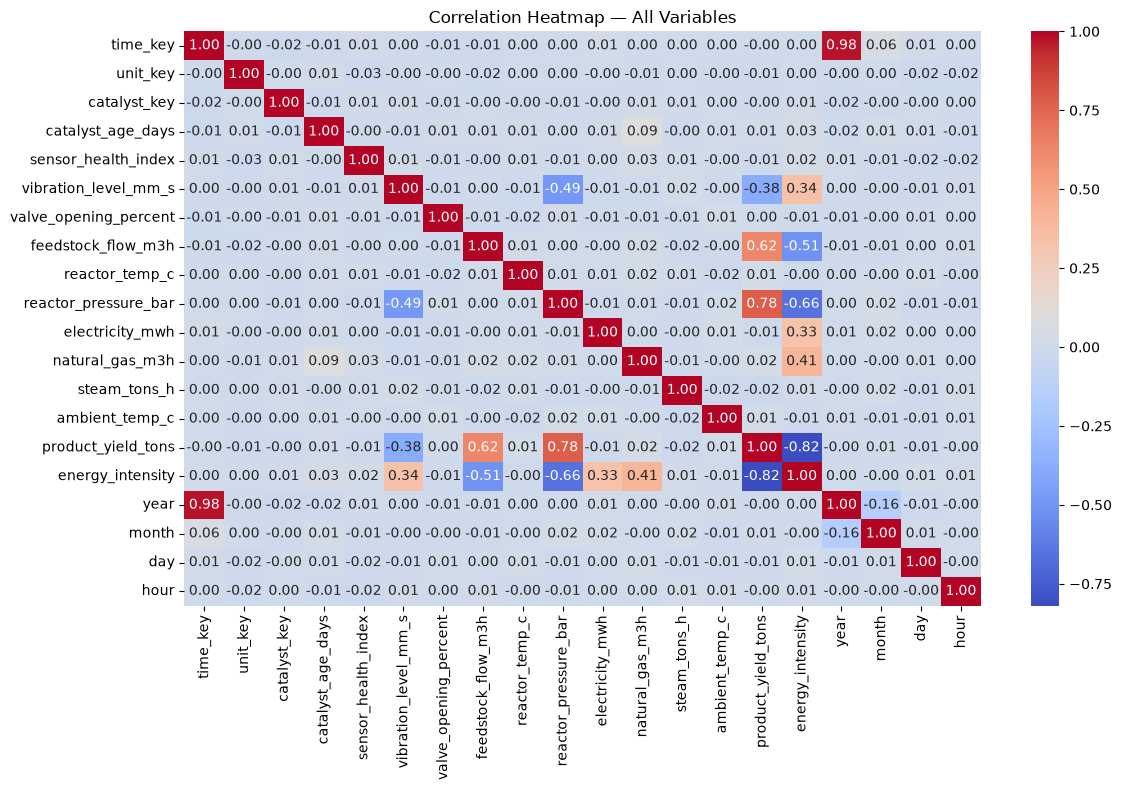

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
numeric_cols = df_analysis.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — All Variables')
plt.tight_layout()
plt.show()

"A correlation heatmap was generated to visualize relationships across all numeric variables. The heatmap confirmed the previously identified key drivers of yield (pressure, flow, vibration, energy intensity) while showing negligible correlation between reactor pressure and feedstock flow (r ≈ 0.00), indicating these two variables independently contribute to yield rather than representing overlapping information. The heatmap also revealed a moderate negative correlation between reactor pressure and vibration level (r = −0.49), suggesting that operating at higher pressure is associated with somewhat lower equipment vibration. Additionally, reactor pressure showed a moderate negative correlation with energy intensity (r = −0.66), indicating that higher-pressure operation tends to coincide with better energy efficiency — consistent with the earlier finding that high-yield, low-energy states are associated with higher pressure conditions."